# ch315 — Pooling and Receptive Fields

## 1. Why pool?

After convolution, feature maps are still large spatial tensors. Pooling serves two purposes:
1. **Spatial downsampling**: reduces computation in subsequent layers.
2. **Translation invariance** (approximate): a small shift in the input changes which
   pool window a feature lands in but not necessarily the pool output — making the
   representation more robust to position.

*(Convolutions: ch314. Approximation and quantisation: ch026.)*

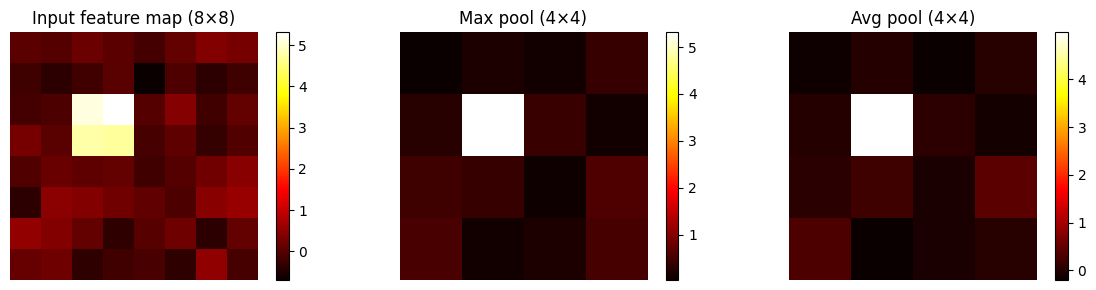

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def max_pool2d(X: np.ndarray, size: int = 2, stride: int = 2) -> np.ndarray:
    """X: (B, C, H, W). Returns (B, C, Ho, Wo)."""
    B, C, H, W = X.shape
    Ho = (H - size) // stride + 1
    Wo = (W - size) // stride + 1
    out = np.zeros((B, C, Ho, Wo))
    for i in range(Ho):
        for j in range(Wo):
            out[:, :, i, j] = X[:, :, i*stride:i*stride+size, j*stride:j*stride+size].max((2, 3))
    return out

def avg_pool2d(X: np.ndarray, size: int = 2, stride: int = 2) -> np.ndarray:
    """Average pooling."""
    B, C, H, W = X.shape
    Ho = (H - size) // stride + 1
    Wo = (W - size) // stride + 1
    out = np.zeros((B, C, Ho, Wo))
    for i in range(Ho):
        for j in range(Wo):
            out[:, :, i, j] = X[:, :, i*stride:i*stride+size, j*stride:j*stride+size].mean((2, 3))
    return out

def global_avg_pool2d(X: np.ndarray) -> np.ndarray:
    """(B, C, H, W) → (B, C)."""
    return X.mean((2, 3))


# Visualise max vs avg pooling on a feature map
rng = np.random.default_rng(0)
feat = np.zeros((1, 1, 8, 8))
feat[0, 0, 2:4, 2:4] = 5.0  # a strong activation cluster
feat += rng.normal(0, 0.3, feat.shape)

mp = max_pool2d(feat, 2, 2)[0, 0]
ap = avg_pool2d(feat, 2, 2)[0, 0]

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, data, title in zip(axes, [feat[0,0], mp, ap],
                            ['Input feature map (8×8)', 'Max pool (4×4)', 'Avg pool (4×4)']):
    im = ax.imshow(data, cmap='hot'); ax.set_title(title); ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig('ch315_pooling.png', dpi=120)
plt.show()

In [2]:
# Receptive field calculation
def receptive_field(layers: list) -> int:
    """
    Calculate the receptive field given a list of (type, kernel, stride) tuples.
    type: 'conv' or 'pool'
    """
    rf = 1; stride_prod = 1
    for layer_type, kernel, stride in layers:
        rf += (kernel - 1) * stride_prod
        stride_prod *= stride
    return rf

# Example: a typical small CNN
architecture = [
    ('conv', 3, 1),  # Conv 3x3, stride 1
    ('pool', 2, 2),  # MaxPool 2x2, stride 2
    ('conv', 3, 1),  # Conv 3x3, stride 1
    ('pool', 2, 2),  # MaxPool 2x2, stride 2
    ('conv', 3, 1),  # Conv 3x3, stride 1
]

cumulative_rf = []
for i in range(1, len(architecture)+1):
    cumulative_rf.append((architecture[i-1][0], receptive_field(architecture[:i])))

print("Receptive field growth:")
for name, rf in cumulative_rf:
    print(f"  After {name}: {rf}×{rf} pixels")

# Show effect of GAP vs flattening
B, C, H, W = 4, 32, 7, 7
feat_maps = np.random.normal(0, 1, (B, C, H, W))
gap_output = global_avg_pool2d(feat_maps)
flat_output = feat_maps.reshape(B, -1)
print(f"\nGlobal Average Pooling: {feat_maps.shape} → {gap_output.shape}")
print(f"Flatten:               {feat_maps.shape} → {flat_output.shape}")
print(f"\nGAP saves {(flat_output.shape[1]-gap_output.shape[1])/flat_output.shape[1]*100:.0f}%"
      f" of classifier parameters (C×H×W vs C).")

Receptive field growth:
  After conv: 3×3 pixels
  After pool: 4×4 pixels
  After conv: 8×8 pixels
  After pool: 10×10 pixels
  After conv: 18×18 pixels

Global Average Pooling: (4, 32, 7, 7) → (4, 32)
Flatten:               (4, 32, 7, 7) → (4, 1568)

GAP saves 98% of classifier parameters (C×H×W vs C).


## 2. Global Average Pooling (GAP)

Introduced in Network in Network (Lin et al., 2013) and used in ResNet, GAP replaces
the flat FC layers at the network's end with a single average over each feature map:

$$h_c = \frac{1}{H \times W} \sum_{i,j} x_{c,i,j}$$

This forces each feature map to become a class confidence map and dramatically reduces
parameters. A 7×7×512 feature map becomes a 512-dim vector — no 25,088-dim flattening.

## 3. Summary

- Max pooling: keeps the strongest activation in each window. Translation invariant.
- Average pooling: smoother; preserves all activations equally.
- Global average pooling: collapse spatial dimensions entirely — one value per channel.
- Receptive field = how many input pixels influence one output neuron. Grows with depth.

## 4. Forward and backward references

**Used here:** conv layers *(ch314)*, spatial feature maps *(ch314)*.

**This will reappear in ch316 — CNN Architectures**, where pooling placement decisions
define the spatial resolution at each stage of VGG, ResNet, and EfficientNet.